In [134]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from matplotlib import pyplot as plt
import sys
import matplotlib.pyplot as plt
from pathlib import Path

# add repo root so swiss_roll_models can be imported from anywhere
for p in [Path.cwd(), *Path.cwd().parents]:
    if (p / "swiss_roll_models").exists():
        sys.path.insert(0, str(p))
        break

from swiss_roll_models.environment.dataset import generate_swiss_roll
from swiss_roll_models.environment.hilbert_distance import hilbert_analysis as hda
from swiss_roll_models.environment.Hilbert_computation import hilbert_computation as hbc
import swiss_roll_models.environment.graph_print_analysis as gp_tools
# positive linear model = softplus(theta) ∈ R^D_{>0}
class PositiveLinear(nn.Module):
    def __init__(self, D):
        super().__init__()
        self.theta = nn.Parameter(torch.zeros(D))  # trainable parameters
    def forward(self, X):
        w = F.softplus(self.theta)
        return X @ w

    def positive_params_vector(self):
        # Return the current positive parameter vector for Hilbert distance calculation
        return F.softplus(self.theta).detach().clone()


In [135]:
def run_experiment_on_subset(
    X_full : torch.Tensor,
    y_full : torch.Tensor,
    n: int,
    num_epochs : int = 500,
    lr : float = 1e-2,
    l2_reg : float = 1e-3,
    device : str = 'cuda',
    seed : int = 114514,
    batch_size : int = None,
) -> dict:
        
    """
    Run training on a random subset of size n from (X_full, y_full).
        Args:
            X_full: Full input data tensor of shape (N, D).
            y_full: Full target data tensor of shape (N,).
            n: Size of the subset to sample for training.
            num_epochs: Number of training epochs.
            lr: Learning rate for SGD.
            l2_reg: L2 regularization coefficient.
            device: Device to run the computations on ("cuda" or "cpu").

        Returns:
            A dictionary containing:
                - 'n': The subset size used.
                - 'loss_traj': List of loss values per epoch.
                - 'param_traj': List of parameter vectors per epoch.
                - 'w_star': Final learned positive parameter vector.
    """
    if batch_size is None:
        batch_size = n  # full-batch
    torch.manual_seed(seed)
    N, D = X_full.shape
    idx = torch.randperm(N, device=device)[:n]
    X = X_full[idx]
    y = y_full[idx]
    dataset = TensorDataset(X, y)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)  # full-batch

    model = PositiveLinear(D).to(device)
    optimizer = torch.optim.SGD(model.parameters(), lr=lr)

    param_traj = []
    loss_traj = []
    mse_traj = []
    l2_traj = []
    theta_traj = []

    for epoch in range(num_epochs):
        for batch_X, batch_y in loader:
            optimizer.zero_grad()

            # 1. prediction
            y_pred = model(batch_X)

            # 2. MSE part
            mse = F.mse_loss(y_pred, batch_y)

            # 3. L2 regularization: regularize w = softplus(theta) in the positive cone
            w = F.softplus(model.theta)
            l2 = (w ** 2).sum()

            # 4. Total loss = mse + λ ||w||^2
            loss = mse + l2_reg * l2

            loss.backward()
            optimizer.step()
        with torch.no_grad():
            theta_t=model.theta.detach().cpu().clone()
            w_t=model.positive_params_vector().cpu().clone()
        loss_traj.append(loss.item())
        mse_traj.append(mse.item())
        l2_traj.append(l2.item())
        param_traj.append(w_t)
        theta_traj.append(theta_t)


    w_star = param_traj[-1]

    prev = param_traj[0]
    return {
        "n": n,
        "num_epochs": num_epochs,
        "lr": lr,
        "l2_reg": l2_reg,
        "seed": seed,
        "loss_traj": loss_traj,
        "mse_traj": mse_traj,
        "l2_traj": l2_traj,
        "param_traj": param_traj,   # list length = num_epochs+1
        "theta_traj": theta_traj,   # optional, to observe inside/outside the cone
        "w_star": w_star,
    }


In [136]:

from matplotlib.ticker import MaxNLocator


device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

# ----- Generate Swiss roll -----
N = 50_000
D = 64
X_full, y_full, u, v = generate_swiss_roll(
    n_samples=N,
    D=D,
    noise=10,
    device=device,
)
print(f"Full dataset: X={X_full.shape}, y={y_full.shape}")

# ----- Different small sample sizes -----
n_list = [50, 100, 200, 500]
num_epochs = 150
lr = 1e-3
l2_list = [0,1e-3,1e-2,1e-1]
l2 = l2_list[2]
first_20s=[]
other_20s=[]
# all_results[n][l2_reg] = corresponding experiment results
all_results = {}
n=9128
names=[]

Using device: cuda
Full dataset: X=torch.Size([50000, 64]), y=torch.Size([50000])


In [137]:

for n in n_list:
    print(f"\n================ n = {n} ================")
    title = f"n={n} and l2_reg={l2}"
    print(f"\n--- Running experiment as {title} ---")
    res = run_experiment_on_subset(
        X_full,
        y_full,
        n=50,
        # num_epochs=num_epochs,
        lr=lr,
        l2_reg= l2,
        device=device,
        seed=27189045,
    )
    names.append(title)
    all_results[title] = res  
    w = res['w_star']
    trajectory = res['param_traj']
    first_20_param = trajectory[:20]
    w_20 = trajectory[20]
    other_20_param = trajectory[20:-1]
    hdist_traj=hbc.compute_hilbert_to_w_star(trajectory=first_20_param, w_star=w_20)
    hdist_traj2=hbc.compute_hilbert_to_w_star(trajectory=other_20_param, w_star=trajectory[-1])
    first_20 = hdist_traj
    other_20 = hdist_traj2
    first_20s.append(first_15)
    other_20s.append(other_20)
    




================ n = 50 ================

--- Running experiment as n=50 and l2_reg=0.01 ---

================ n = 100 ================

--- Running experiment as n=100 and l2_reg=0.01 ---

================ n = 200 ================

--- Running experiment as n=200 and l2_reg=0.01 ---

================ n = 500 ================

--- Running experiment as n=500 and l2_reg=0.01 ---


4


<Figure size 800x600 with 0 Axes>

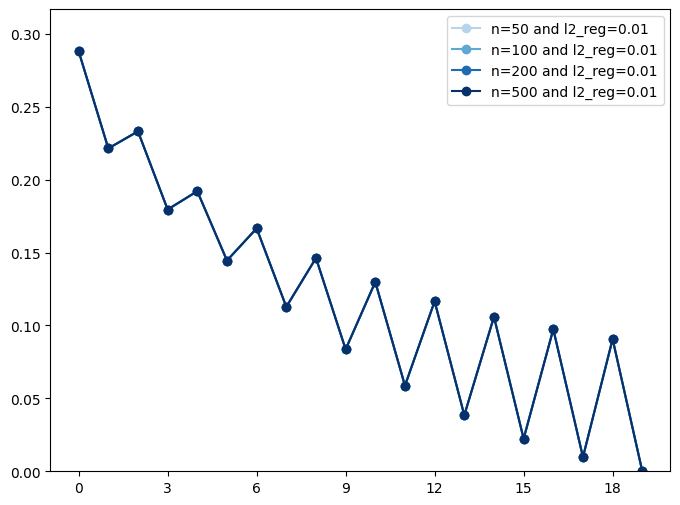

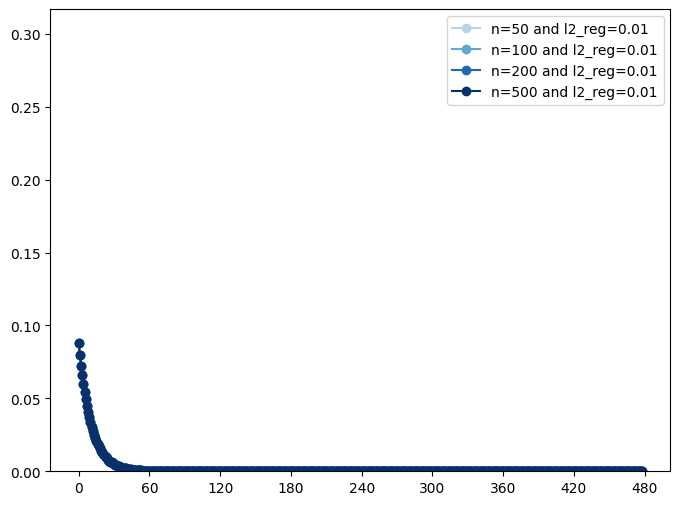

In [138]:
fig = plt.figure(figsize=(8, 6))
y_min = 0
y_max = max(
    max(max(group) for group in first_20s),
    max(max(group) for group in other_20s)
) * 1.1
print(len(first_20s))
import matplotlib.cm as cm
plt.figure(figsize=(8, 6)) 
plt.ylim(y_min, y_max)
plt.xscale('linear')
plt.yscale('linear')
plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))
num_groups = len(first_20s)

start, end = 0.3, 1.0
colors = cm.Blues([start + (end - start) * i / (num_groups - 1) for i in range(num_groups)])
for i, first_20 in enumerate(first_20s):
    first_20
    plt.plot(range(len(first_20)), first_20, marker='o', color=colors[i],label=names[i])

plt.legend()
plt.show()


plt.figure(figsize=(8, 6))
plt.ylim(y_min, y_max)
plt.xscale('linear')
plt.yscale('linear')
plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))
for i, other_20 in enumerate(other_20s):
    plt.plot(range(len(other_20)), other_20, marker='o', color=colors[i],label=names[i])
plt.legend()
plt.show()

In [139]:
import numpy as np
print(all_results.keys())
res=all_results[names[3]]

dict_keys(['n=50 and l2_reg=0.01', 'n=100 and l2_reg=0.01', 'n=200 and l2_reg=0.01', 'n=500 and l2_reg=0.01'])


In [140]:
hilbert_to_final=hbc.compute_hilbert_to_w_star(res['param_traj'],res['w_star'],)
l2_to_final=np.linalg.norm(np.array(res['param_traj'])-res['w_star'].cpu().numpy(),axis=1)
loss_traj=res['loss_traj']

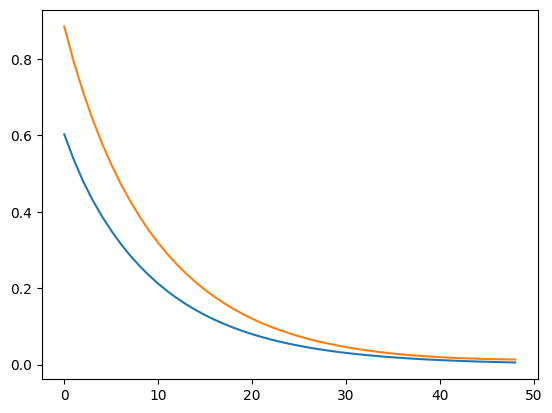

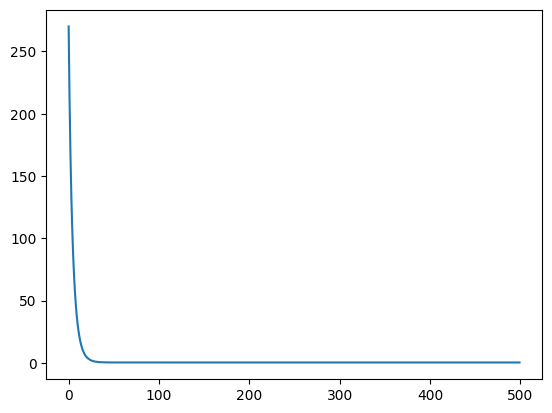

In [141]:
plt.plot(hilbert_to_final[1:50],label='Hilbert distance to final')
plt.plot(l2_to_final[1:50],label='L2 distance to final')
plt.show()
plt.plot(loss_traj,label='Loss trajectory')

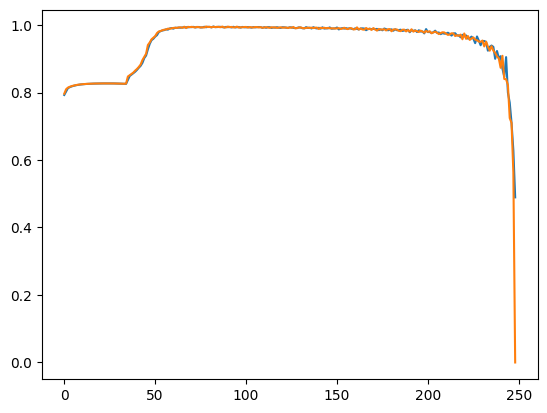

In [142]:
h = np.array(hilbert_to_final)
h_even = h[0::2]
h_odd  = h[1::2]

ratio_even = h_even[1:] / h_even[:-1]   # 每两步之间的收缩比例，真正对应 |λ|^2
ratio_odd  = h_odd[1:] / h_odd[:-1]
plt.plot(ratio_even,label='Even step ratio')
plt.plot(ratio_odd,label='Odd step ratio')

In [143]:
from sklearn.decomposition import PCA
trajectory = res['param_traj']
w_traj = np.array(trajectory[1:20])    # shape: (T+1, D)
w_star = res['w_star'].cpu().numpy()  # shape: (D,
R = w_traj - w_star          # shape: (T+1, D)
pca = PCA(n_components=1)
pca.fit(R)
v = pca.components_[0]       # 主方向，单位向量

a = R @ v                    # shape: (T+1,)
print('first 20 largest eigenvalue',a)
numpy_hilbert_to_final20=np.array(hilbert_to_final[:20])
print('hilbert to final first 20 steps',numpy_hilbert_to_final20)


first 20 largest eigenvalue [-0.88504946 -0.7937493  -0.7132542  -0.6419453  -0.578528   -0.521949
 -0.47133726 -0.4259636  -0.3852105  -0.34854984 -0.31552655 -0.28574562
 -0.25886208 -0.23457338 -0.21261269 -0.19274396 -0.17475793 -0.1584677
 -0.14370714]
hilbert to final first 20 steps [0.67800961 0.60286557 0.53746387 0.48022821 0.43142689 0.38878305
 0.35070217 0.31662479 0.28607545 0.25864634 0.23398522 0.21178661
 0.19178347 0.17374212 0.15745705 0.14274623 0.12944895 0.11742254
 0.10653962 0.09668686]


In [144]:
hilbert_to_betwee=hbc.compute_hilbert_between_steps(res['param_traj'])
vector_hilbert_between_steps=np.array(hilbert_to_betwee)
print(vector_hilbert_between_steps[:20])
ratio_to_between=vector_hilbert_between_steps[1:20]/vector_hilbert_between_steps[0:19]


[0.07641559 0.06615668 0.05760761 0.05041198 0.04441418 0.03933138
 0.03493028 0.03109786 0.02774596 0.02480165 0.02220648 0.02000314
 0.01804135 0.01628507 0.01471082 0.01329729 0.0120264  0.01088292
 0.00985277 0.00892382]
